In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier 
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier

In [102]:
# Loading in the train.csv
df = pd.read_csv('train.csv', na_values=["?"], low_memory=False)
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0.0,0.0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0.0,0.0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0.0,1.0
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0.0,0.0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0.0,0.0


In [103]:
# Figuring out the distribution of NaN values in the dataset

# Total NaN
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

# Amonut of NaN per features
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_df = pd.DataFrame({"NaN Count": nan_counts, "NaN %": nan_pct})
nan_df = nan_df[nan_df["NaN Count"] > 0].sort_values("NaN %", ascending=False)
print(nan_df.to_string())

Total NaN values: 1,131,642
Total cells:      4,120,215
Missing overall:  27.5%

                      NaN Count  NaN %
BIRD_BAND_NUMBER          74731  99.76
ENG_4_POS                 74134  98.96
ENROUTE_STATE             73604  98.25
PRECIPITATION             72109  96.26
ENG_3_POS                 71853  95.92
LOCATION                  65324  87.20
SPEED                     51518  68.77
NUM_SEEN                  51010  68.09
SKY                       39612  52.88
FLT                       39172  52.29
HEIGHT                    37495  50.05
TIME_OF_DAY               32640  43.57
PHASE_OF_FLIGHT           29380  39.22
REG                       28915  38.60
AMO                       28304  37.78
EMO                       27492  36.70
TIME                      26592  35.50
DISTANCE                  25216  33.66
COMMENTS                  25107  33.51
ENG_2_POS                 24889  33.22
EMA                       24880  33.21
AMA                       21556  28.77
TYPE_ENG              

In [104]:
# Dropping features due to high precentage of NaN
# Additionally dropping random features that act as Identifiers (i.e. INCIDENT_DATE, FLT, REG, LUPDATE, TRANSFER)
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
df.drop(columns=drop_cols, inplace=True)

In [105]:
# Fill the numeric features's NaN value with there respective median  
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]

train_medians = {}
for col in num_cols:
    if col in df.columns:
        train_medians[col] = df[col].median()
        df[col].fillna(train_medians[col], inplace=True)


/tmp/ipykernel_2429921/4061943497.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(train_medians[col], inplace=True)
/tmp/ipykernel_2429921/4061943497.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never wo

In [106]:
# Fill the categorical features's NaN with "Unknow"
cat_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
            "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
            "FAAREGION", "PERSON", "SOURCE"]
for col in cat_cols:
    if col in df.columns:
        df[col].fillna("Unknown", inplace=True)

/tmp/ipykernel_2429921/1571190423.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna("Unknown", inplace=True)


In [107]:
# Fill NUM_STRUCK feature with 1 (most common single-bird strike)
df["NUM_STRUCK"] = pd.to_numeric(df["NUM_STRUCK"], errors="coerce")
df["NUM_STRUCK"].fillna(1, inplace=True)

# Fill NUM_SEEN feature with median
df["NUM_SEEN"] = pd.to_numeric(df["NUM_SEEN"], errors="coerce")
train_medians["NUM_SEEN"] = df["NUM_SEEN"].median()
df["NUM_SEEN"].fillna(train_medians["NUM_SEEN"], inplace=True)

/tmp/ipykernel_2429921/396433350.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["NUM_STRUCK"].fillna(1, inplace=True)
/tmp/ipykernel_2429921/396433350.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to upd

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
74908    1.0
74909    1.0
74910    1.0
74911    1.0
74912    1.0
Name: NUM_SEEN, Length: 74913, dtype: float64

In [108]:
# Checking NaN percentage
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

Total NaN values: 615,400
Total cells:      3,146,346
Missing overall:  19.6%



In [109]:
# Convert TIME (HH:MM string) to numeric HOUR, then drop original
# Missing TIME values are imputed with the median hour
df["HOUR"] = pd.to_numeric(
    df["TIME"].str.split(":").str[0], errors="coerce"
)
train_medians["HOUR"] = df["HOUR"].median()
df["HOUR"] = df["HOUR"].fillna(train_medians["HOUR"])
df.drop(columns=["TIME"], inplace=True)

# Drop LATITUDE/LONGITUDE — redundant with STATE and FAAREGION
df.drop(columns=["LATITUDE", "LONGITUDE"], inplace=True)

print("HOUR sample:", df["HOUR"].describe())
print("\nRemaining NaNs:", df.isnull().sum().sum())

HOUR sample: count    74913.000000
mean        12.586480
std          4.637517
min          0.000000
25%         11.000000
50%         12.000000
75%         14.000000
max         23.000000
Name: HOUR, dtype: float64

Remaining NaNs: 568897


In [110]:
# Class balance check
print("Class counts:")
print(df["INDICATED_DAMAGE"].value_counts())

print("\nClass percentages:")
print(df["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))


Class counts:
INDICATED_DAMAGE
0.0    70154
1.0     4758
Name: count, dtype: int64

Class percentages:
INDICATED_DAMAGE
0.0    93.65
1.0     6.35
Name: proportion, dtype: float64


In [111]:
# Scaling the data set 
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Encoding the categorical columns
label_encoders = {}  # store one encoder per column so we can reuse on test set
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le # save for test set later
    
# Seperating features and target 
X = df.drop(columns=["INDICATED_DAMAGE", "INDEX_NR"])
y = df["INDICATED_DAMAGE"]

# Scaling Numeric Features
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete. Shape:", X_scaled.shape)
print(X_scaled.describe().round(2))

Scaling complete. Shape: (74913, 38)


/tmp/ipykernel_2429921/2864705587.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


       INCIDENT_MONTH  INCIDENT_YEAR  TIME_OF_DAY  AIRPORT_ID   AIRPORT  \
count        74913.00       74913.00     74913.00    74913.00  74913.00   
mean            -0.19          -0.11        -0.11        0.05      0.00   
std              0.69           0.69         0.46        0.61      0.52   
min             -1.75          -1.92        -1.00       -1.25     -0.92   
25%             -0.75          -0.54        -0.67       -0.55     -0.54   
50%              0.00           0.00         0.00        0.00      0.00   
75%              0.25           0.46         0.33        0.45      0.46   
max              1.00           0.85         0.33        1.09      0.82   

         RUNWAY     STATE  FAAREGION      OPID  OPERATOR  ...  \
count  74913.00  74913.00   74913.00  74913.00  74913.00  ...   
mean       0.07      0.00      -0.08     -0.34     -0.32  ...   
std        0.56      0.50       0.54      0.55      0.53  ...   
min       -1.04     -0.81      -1.20     -1.27     -1.38  ...   

In [112]:
# Reading in the test dataset
test_df = pd.read_csv("test.csv", na_values=["?"], low_memory=False)
test_df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER
0,9000000,7/26/16,7,2016,8:15,Day,KDTW,DETROIT METRO WAYNE COUNTY ARPT,42.21206,-83.34884,...,Unknown,NaN,1,Small,NaN,REMOVED EFFECT OTHER TICK BOX,Multiple,Tower,12/14/21,0
1,9000001,6/27/92,6,1992,NaN,Dawn,KMSY,LOUIE ARMSTRONG NEW ORLEANS INTL ARPT,29.99339,-90.25803,...,No,10-Feb,1,Small,NaN,/Legacy Record 104952/,FAA Form 5200-7,Pilot,8/28/96,0
2,9000002,11/17/23,11,2023,17:37,Dusk,KIND,INDIANAPOLIS INTL ARPT,39.71733,-86.29438,...,Unknown,NaN,1,Small,NaN,*** Strike Report: 2023-11-17-175321-R1( Repor...,Multiple,Airport Operations,3/13/24,0
3,9000003,6/15/09,6,2009,10:45,Day,PHMK,MOLOKAI ARPT,21.15289,-157.09626,...,No,NaN,10-Feb,Small,NaN,2009-6-15-135537 /Legacy Record 264255/,FAA Form 5200-7-E,Tower,11/27/09,0
4,9000004,10/29/90,10,1990,12:29,Day,KBED,LAURENCE G HANSCOM FIELD ARPT,42.46995,-71.28903,...,Yes,1,1,Medium,NaN,LOCATION HANSCOM TOWER (4/28/14 UPDATED ARPT...,FAA Form 5200-7,NaN,4/28/14,0


In [113]:
# Dropping same columns as training
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
test_df.drop(columns=drop_cols, inplace=True)

In [114]:
# Numeric imputation using saved training medians
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]
for col in num_cols:
    if col in test_df.columns:
        test_df[col].fillna(train_medians[col], inplace=True)

/tmp/ipykernel_2429921/423507179.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test_df[col].fillna(train_medians[col], inplace=True)


In [115]:
# Categorical imputation with "Unknown"
cat_fill_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
                 "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
                 "FAAREGION", "PERSON", "SOURCE"]
for col in cat_fill_cols:
    if col in test_df.columns:
        test_df[col].fillna("Unknown", inplace=True)

/tmp/ipykernel_2429921/2916473070.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test_df[col].fillna("Unknown", inplace=True)


In [116]:
# NUM_STRUCK and NUM_SEEN using saved training medians
test_df["NUM_STRUCK"] = pd.to_numeric(test_df["NUM_STRUCK"], errors="coerce")
test_df["NUM_STRUCK"].fillna(1, inplace=True)

/tmp/ipykernel_2429921/2515565632.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test_df["NUM_STRUCK"].fillna(1, inplace=True)


0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
34126    1.0
34127    1.0
34128    1.0
34129    1.0
34130    1.0
Name: NUM_STRUCK, Length: 34131, dtype: float64

In [117]:
# TIME → HOUR using saved training median, drop LAT/LON
test_df["HOUR"] = pd.to_numeric(
    test_df["TIME"].str.split(":").str[0], errors="coerce"
)
test_df["HOUR"] = test_df["HOUR"].fillna(train_medians["HOUR"])
test_df.drop(columns=["TIME", "LATITUDE", "LONGITUDE"], inplace=True)

In [118]:
# Label encode using saved encoders from training
for col in cat_cols:
    test_df[col] = test_df[col].astype(str).map(
        lambda x, le=label_encoders[col]: le.transform([x])[0]
        if x in le.classes_ else -1
    )

In [119]:
# Save INDEX_NR before dropping
index_nr = test_df["INDEX_NR"]
X_test = test_df.drop(columns=["INDEX_NR"])

# Force convert every column, catches mixed type columns the dtype check misses
# THIS SECTION IS CLAUDE
for col in X_test.columns:
    try:
        X_test[col] = X_test[col].astype(float)
    except (ValueError, TypeError):
        print(f"Encoding: {col} | sample values: {X_test[col].unique()[:5]}")
        if col in label_encoders:
            X_test[col] = X_test[col].astype(str).map(
                lambda x, le=label_encoders[col]: le.transform([x])[0]
                if x in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X_test[col] = le.fit_transform(X_test[col].astype(str))
            print(f"  Warning: {col} was not in label_encoders, fit new encoder")

# Scale
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Test set ready. Shape:", X_test_scaled.shape)
print("Remaining NaNs:", X_test_scaled.isnull().sum().sum())

Encoding: NUM_SEEN | sample values: <StringArray>
[nan, '10-Feb', '1', '11-100', 'More than 100']
Length: 5, dtype: str
Test set ready. Shape: (34131, 38)
Remaining NaNs: 121236


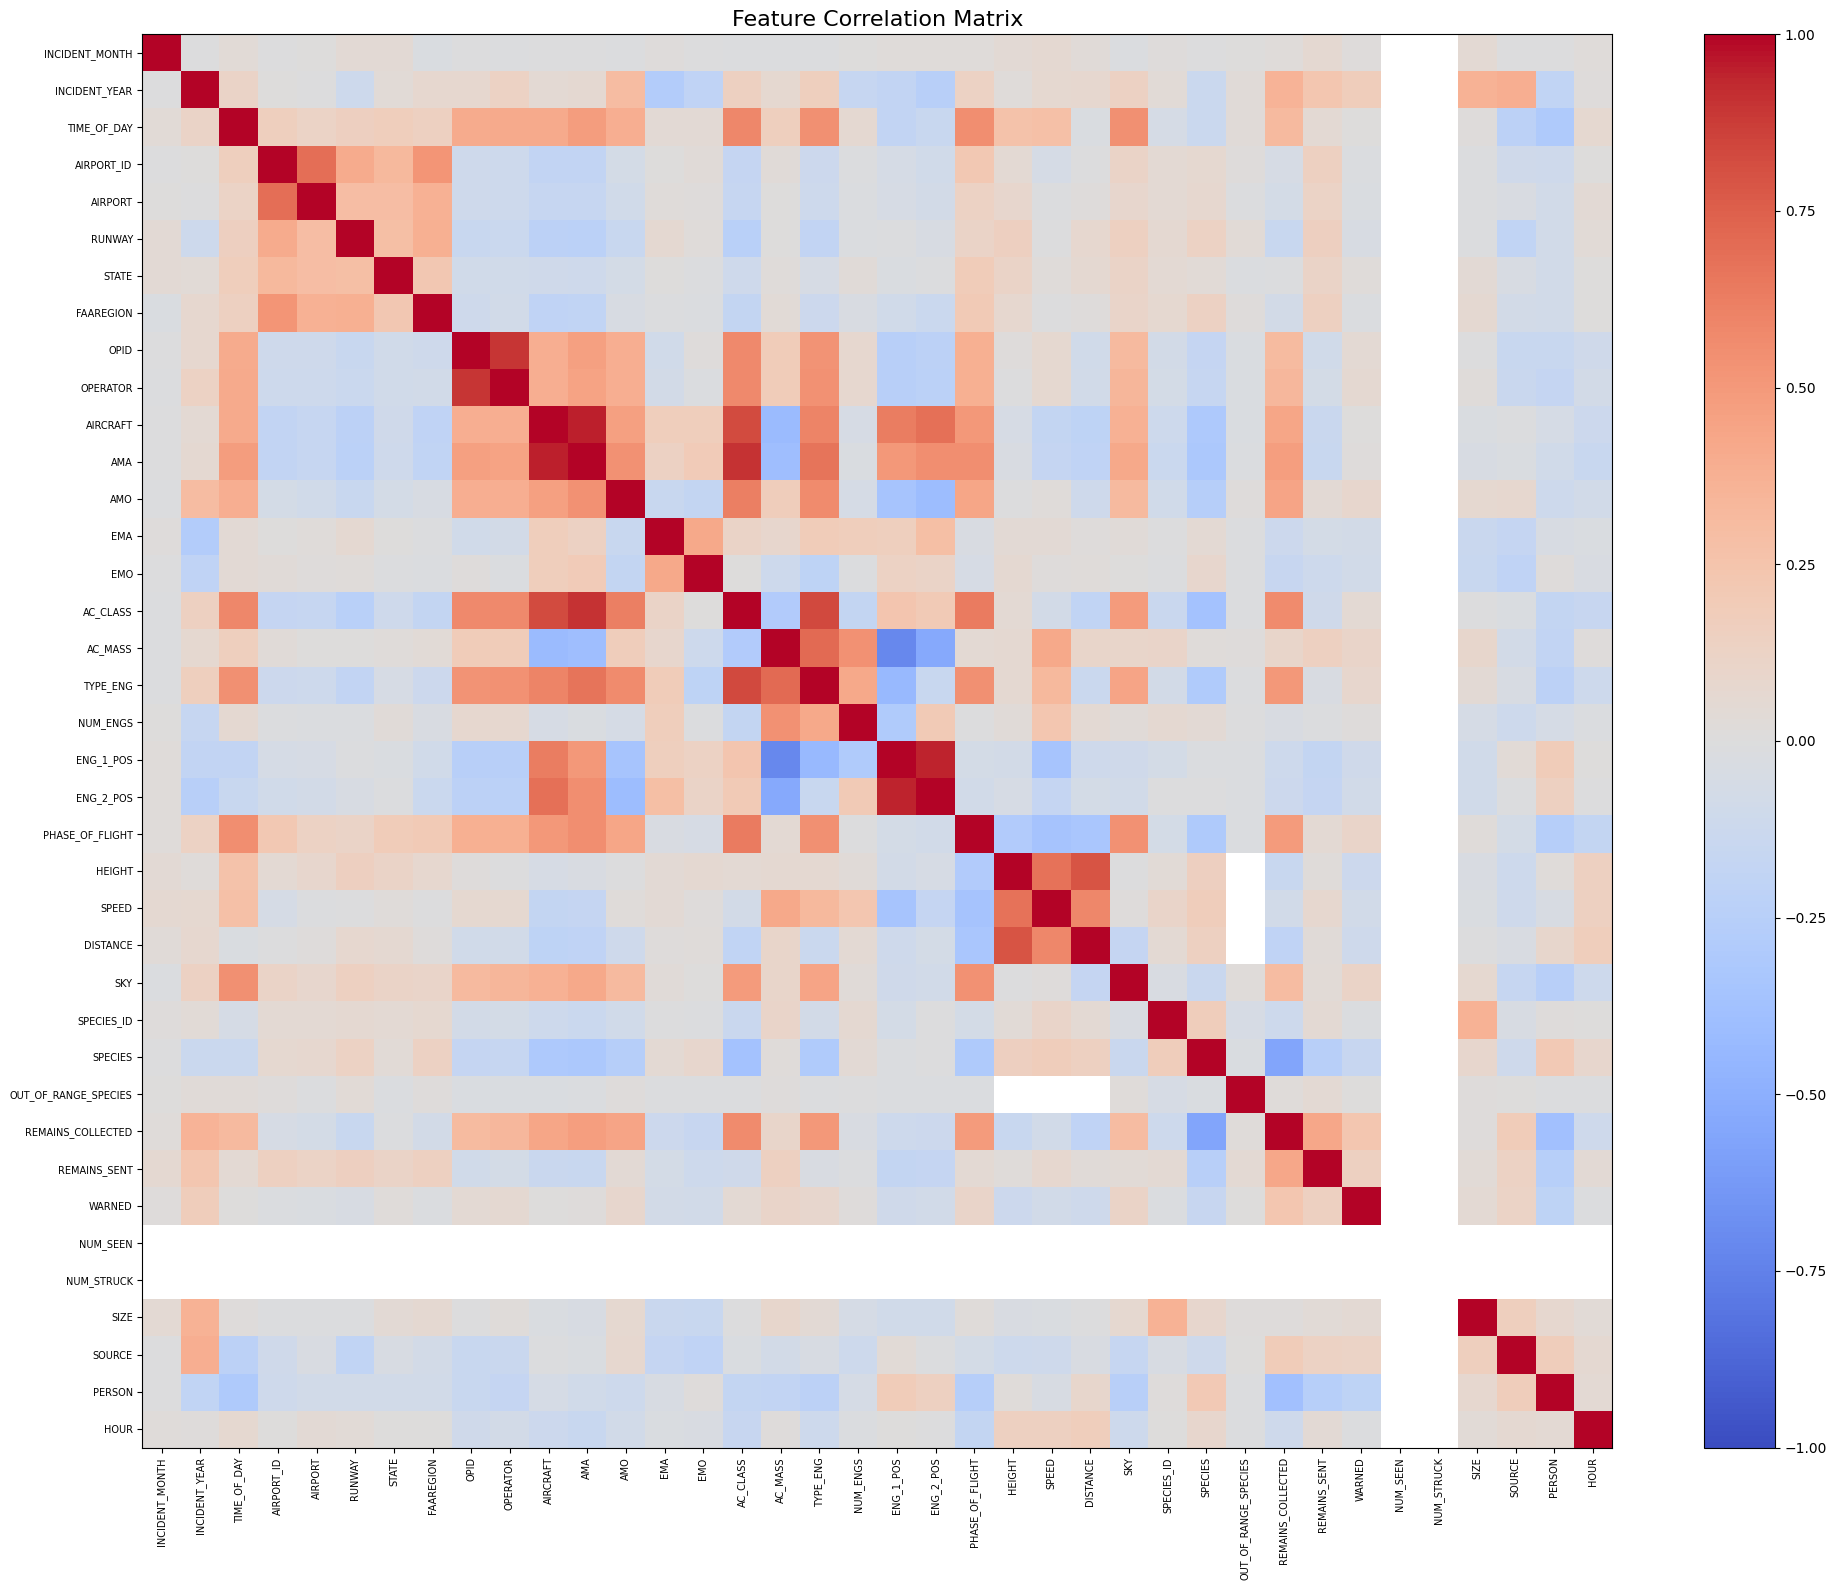

Top 15 features most correlated with INDICATED_DAMAGE:
SIZE                 0.269201
TYPE_ENG             0.219449
AC_MASS              0.196437
AC_CLASS             0.151609
INCIDENT_YEAR        0.140064
SPECIES_ID           0.137083
OPERATOR             0.133362
PHASE_OF_FLIGHT      0.131049
AMO                  0.127508
ENG_1_POS            0.124043
REMAINS_COLLECTED    0.119927
OPID                 0.118836
AMA                  0.111195
SKY                  0.107780
TIME_OF_DAY          0.101072
dtype: float64


/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [120]:
# Making similarity matrix to see if data is clusterable (We aren't clustering)
# Sample 5000 rows — computing on 307k rows is too slow
X_sample = X_scaled.sample(n=5000, random_state=42)

corr_matrix = X_sample.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Add colorbar
plt.colorbar(im, ax=ax)

# Add feature labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# Top features correlated with target 
target_corr = X_scaled.corrwith(y.reset_index(drop=True)).abs().sort_values(ascending=False)
print("Top 15 features most correlated with INDICATED_DAMAGE:")
print(target_corr.head(15))


In [121]:
# Dropping featues that have near-zero variance
zero_var_cols = ["NUM_SEEN", "NUM_STRUCK", "OUT_OF_RANGE_SPECIES"]
for col in zero_var_cols:
    if col in X_scaled.columns:
        X_scaled = X_scaled.drop(columns=[col])

# Drop zero-variance columns from test set
for col in zero_var_cols:
    if col in X_test_scaled.columns:
        X_test_scaled = X_test_scaled.drop(columns=[col])

print("Remaining training features:", X_scaled.shape[1])
print("Remaining test features:", X_test_scaled.shape[1])

Remaining training features: 35
Remaining test features: 35


In [122]:
# Fill any remaining NaNs with 0 (= median after RobustScaler)
X_scaled = X_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

print("NaNs remaining in X_scaled:", X_scaled.isnull().sum().sum())
print("NaNs remaining in X_test_scaled:", X_test_scaled.isnull().sum().sum())

# Reset and clean y before model training
y = df["INDICATED_DAMAGE"].reset_index(drop=True)

# Drop any rows where target is NaN
mask = y.notna()
y = y[mask].reset_index(drop=True)
X_scaled = X_scaled[mask].reset_index(drop=True)

print("NaNs in y:", y.isnull().sum())
print("X_scaled shape:", X_scaled.shape)
print("Class counts:\n", y.value_counts())

NaNs remaining in X_scaled: 0
NaNs remaining in X_test_scaled: 0
NaNs in y: 0
X_scaled shape: (74912, 35)
Class counts:
 INDICATED_DAMAGE
0.0    70154
1.0     4758
Name: count, dtype: int64


In [123]:
X_scaled, _, y, _ = train_test_split(
    X_scaled, y,
    train_size=0.3,
    stratify=y,      # preserves the 93/6 class balance
    random_state=42
)
print("Reduced training size:", X_scaled.shape)

Reduced training size: (22473, 35)


In [ ]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle class imbalance (replaces class_weight="balanced")
neg = (y == 0).sum()
pos = (y == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

xgb_params = {
    "n_estimators":     [200, 300, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [3, 5, 7],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma":            [0, 0.1, 0.5],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 2, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale,   # handles 93/6 imbalance
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    xgb_params, n_iter=20, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
xgb_search.fit(X_scaled, y)
best_xgb = xgb_search.best_estimator_

xgb_scores = cross_val_score(best_xgb, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print(f"XGBoost CV Balanced Accuracy: {xgb_scores.mean():.4f} +/- {xgb_scores.std():.4f}")
print(f"Best params: {xgb_search.best_params_}")

In [ ]:
y_proba_test = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Tune threshold on training data first
y_proba_train = best_xgb.predict_proba(X_scaled)[:, 1]
best_thresh, best_score = 0.5, 0
for thresh in [i/100 for i in range(10, 60)]:
    preds = (y_proba_train >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)
    if score > best_score:
        best_score = score
        best_thresh = thresh

print(f"Best threshold: {best_thresh}, Train Balanced Accuracy: {best_score:.4f}")

# Apply to test set
y_pred_xgb = (y_proba_test >= best_thresh).astype(int)

submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred_xgb
})
submission.to_csv("submission_xgb.csv", index=False)
print(submission["INDICATED_DAMAGE"].value_counts())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# DECISION STUMP (Decision Tree with max_depth=1)
stump_params = {
    "class_weight": ["balanced"],
    "criterion":    ["gini", "entropy"],
    "splitter":     ["best", "random"]
}
stump_search = RandomizedSearchCV(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    stump_params, n_iter=6, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
stump_search.fit(X_scaled, y)
best_stump = stump_search.best_estimator_

stump_scores = cross_val_score(best_stump, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Decision Stump ──")
print(f"  Best params: {stump_search.best_params_}")
print(f"  CV Balanced Accuracy: {stump_scores.mean():.4f} +/- {stump_scores.std():.4f}")

# BAGGING
bagging_params = {
    "n_estimators":      [50, 100, 200],
    "max_samples":       [0.7, 0.8, 1.0],
    "max_features":      [0.7, 0.8, 1.0],
    "bootstrap":         [True, False]
}
bagging_search = RandomizedSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
        random_state=42
    ),
    bagging_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
bagging_search.fit(X_scaled, y)
best_bagging = bagging_search.best_estimator_

bagging_scores = cross_val_score(best_bagging, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Bagging ──")
print(f"  Best params: {bagging_search.best_params_}")
print(f"  CV Balanced Accuracy: {bagging_scores.mean():.4f} +/- {bagging_scores.std():.4f}")

# RANDOM FOREST
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

rf_scores = cross_val_score(best_rf, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Random Forest ──")
print(f"  Best params: {rf_search.best_params_}")
print(f"  CV Balanced Accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

# BOOSTING (Gradient Boosting)
boost_params = {
    "n_estimators":      [100, 200, 300],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "max_depth":         [3, 4, 5],
    "subsample":         [0.7, 0.8, 1.0],
    "min_samples_leaf":  [1, 2, 4]
}
boost_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    boost_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
boost_search.fit(X_scaled, y)
best_boost = boost_search.best_estimator_

boost_scores = cross_val_score(best_boost, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Boosting ──")
print(f"  Best params: {boost_search.best_params_}")
print(f"  CV Balanced Accuracy: {boost_scores.mean():.4f} +/- {boost_scores.std():.4f}")

In [128]:
# MULTICLASS PARTITIONING (One-vs-Rest)
ovr_params = {
    "estimator__C":        [0.01, 0.1, 1, 10],
    "estimator__solver":   ["lbfgs", "saga"],
    "estimator__max_iter": [200, 500]
}
ovr_search = RandomizedSearchCV(
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", random_state=42)),
    ovr_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
ovr_search.fit(X_scaled, y)
best_ovr = ovr_search.best_estimator_

ovr_scores = cross_val_score(best_ovr, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Multiclass Partitioning (OvR) ──")
print(f"  Best params: {ovr_search.best_params_}")
print(f"  CV Balanced Accuracy: {ovr_scores.mean():.4f} +/- {ovr_scores.std():.4f}")

/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/u/kg

── Multiclass Partitioning (OvR) ──
  Best params: {'estimator__solver': 'saga', 'estimator__max_iter': 500, 'estimator__C': 1}
  CV Balanced Accuracy: 0.7800 +/- 0.0127


/u/kg35398/Documents/CS 363M/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# STACKING
stacking = StackingClassifier(
    estimators=[
        ("stump",   best_stump),
        ("bagging", best_bagging),
        ("rf",      best_rf),
        ("boost",   best_boost),
        ("ovr",     best_ovr)
    ],
    final_estimator=LogisticRegression(class_weight="balanced", random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_scaled, y)

stacking_scores = cross_val_score(stacking, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Stacking ──")
print(f"  CV Balanced Accuracy: {stacking_scores.mean():.4f} +/- {stacking_scores.std():.4f}")


# VOTING ENSEMBLE (best models combined)
voting = VotingClassifier(
    estimators=[
        ("stump",    best_stump),
        ("bagging",  best_bagging),
        ("rf",       best_rf),
        ("boost",    best_boost),
        ("ovr",      best_ovr),
        ("stacking", stacking)
    ],
    voting="soft",
    n_jobs=-1
)
voting.fit(X_scaled, y)

voting_scores = cross_val_score(voting, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Voting Ensemble ──")
print(f"  CV Balanced Accuracy: {voting_scores.mean():.4f} +/- {voting_scores.std():.4f}/")

results = {
    "Decision Stump":          stump_scores.mean(),
    "Bagging":                 bagging_scores.mean(),
    "Random Forest":           rf_scores.mean(),
    "Boosting":                boost_scores.mean(),
    "Multiclass Part. (OvR)": ovr_scores.mean(),
    "Stacking":                stacking_scores.mean(),
    "Voting Ensemble":         voting_scores.mean()
}
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<28} {score:.4f}")

print(f"Best model: {max(results, key=results.get)}")
print(f"Best Balanced Accuracy: {max(results.values()):.4f}")

#  Generate predictions using best voting ensemble
y_pred = voting.predict(X_test_scaled)

# Build submission file
submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred
})

submission.to_csv("submission.csv", index=False)
print(submission["INDICATED_DAMAGE"].value_counts())
print(submission["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))